# EPO Data Visualisations & Matching Validation

This notebook loads the processed pkl files generated by `data_processing.py` and produces:
1. Descriptive statistics and visualisations of the EPO dataset
2. Matching validation results (confusion matrices) from manually annotated samples

## Libraries

In [43]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [44]:
# Paths
DATA_DIR = os.path.join(os.getcwd(), '../Data')
MATCHING_DIR = os.path.join(DATA_DIR, 'Matching')

## Load Processed Data

These pkl files are generated by `data_processing.py` (run via SLURM).

In [45]:
# Full cleaned dataset (all case types)
t_df_clean = pd.read_pickle(os.path.join(DATA_DIR, 'EPO_Data.pkl'))
print(f'EPO_Data.pkl: {len(t_df_clean):,} rows')

# Patent Refusal subset with Outcome
binary_refusal_df = pd.read_pickle(os.path.join(DATA_DIR, 'Train&TestData_1.0_PatentRefusal.pkl'))
print(f'PatentRefusal (all outcomes): {len(binary_refusal_df):,} rows')

# Opposition Division with Outcomes
opposition_df_clean = pd.read_pickle(os.path.join(DATA_DIR, 'Train&TestData_1.0_OppositionDivision.pkl'))
print(f'OppositionDivision (all outcomes): {len(opposition_df_clean):,} rows')

# Known-outcome views for visualisations
binary_refusal_known = binary_refusal_df.loc[binary_refusal_df['Outcome'] != 'Unknown'].copy()
opposition_known = opposition_df_clean.loc[opposition_df_clean['Outcome'] != 'Unknown'].copy()
print(f'PatentRefusal (known outcomes): {len(binary_refusal_known):,} rows')
print(f'OppositionDivision (known outcomes): {len(opposition_known):,} rows')

EPO_Data.pkl: 24,464 rows
PatentRefusal (all outcomes): 8,661 rows
OppositionDivision (all outcomes): 14,498 rows
PatentRefusal (known outcomes): 8,661 rows
OppositionDivision (known outcomes): 14,024 rows
OppositionDivision (all outcomes): 14,498 rows
PatentRefusal (known outcomes): 8,661 rows
OppositionDivision (known outcomes): 14,024 rows


## 1. Descriptive Statistics

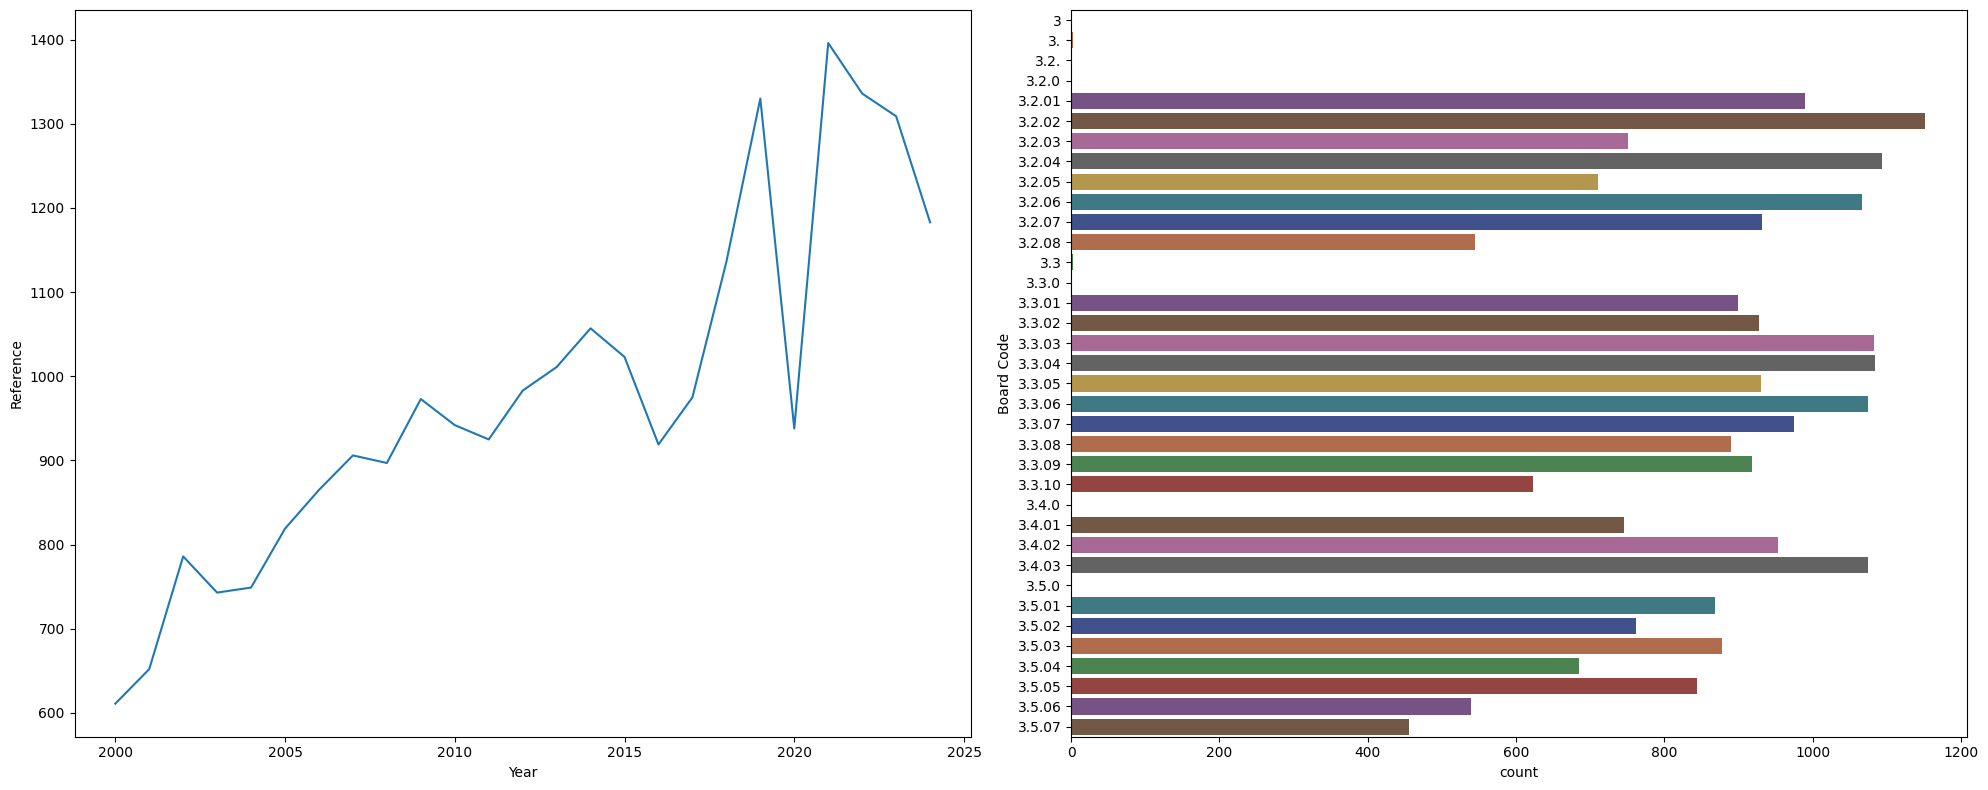

In [46]:
df = t_df_clean

fig, (ax2, ax3) = plt.subplots(1, 2, figsize=(20, 8))

# Court Type by Procedure Language
# sns.countplot(
#     data=df,
#     x='Court Type', hue='Procedure Language',
#     palette='dark', alpha=.6, ax=ax1
# )

# Cases over time
date_group = df.groupby(['Year'], as_index=False).count()
sns.lineplot(data=date_group, x='Year', y='Reference', ax=ax2)

# Board codes
sns.countplot(
    data=df.sort_values('Board Code', ascending=True),
    y='Board Code', hue='Board Code',
    palette='dark', dodge=False, alpha=.8, ax=ax3
)
if ax3.get_legend() is not None:
    ax3.get_legend().remove()

plt.tight_layout()
plt.show()

### Matched Articles Distribution

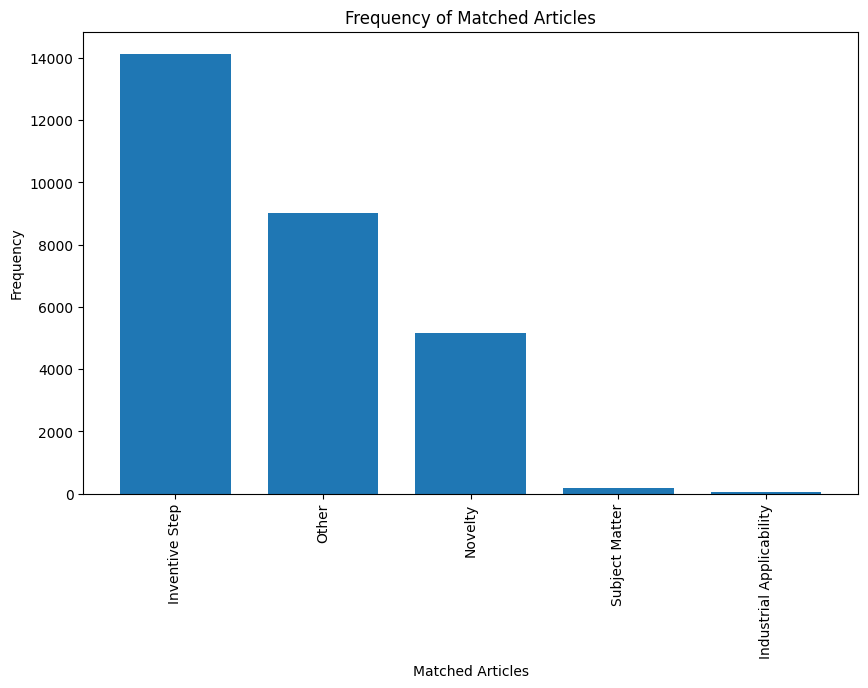

In [47]:
# Frequency of individual matched articles
matched_articles_counts = df['Matched Articles'].explode().value_counts()

plt.figure(figsize=(10, 6))
matched_articles_counts.plot(kind='bar', width=0.75)
plt.title('Frequency of Matched Articles')
plt.xlabel('Matched Articles')
plt.ylabel('Frequency')
plt.show()

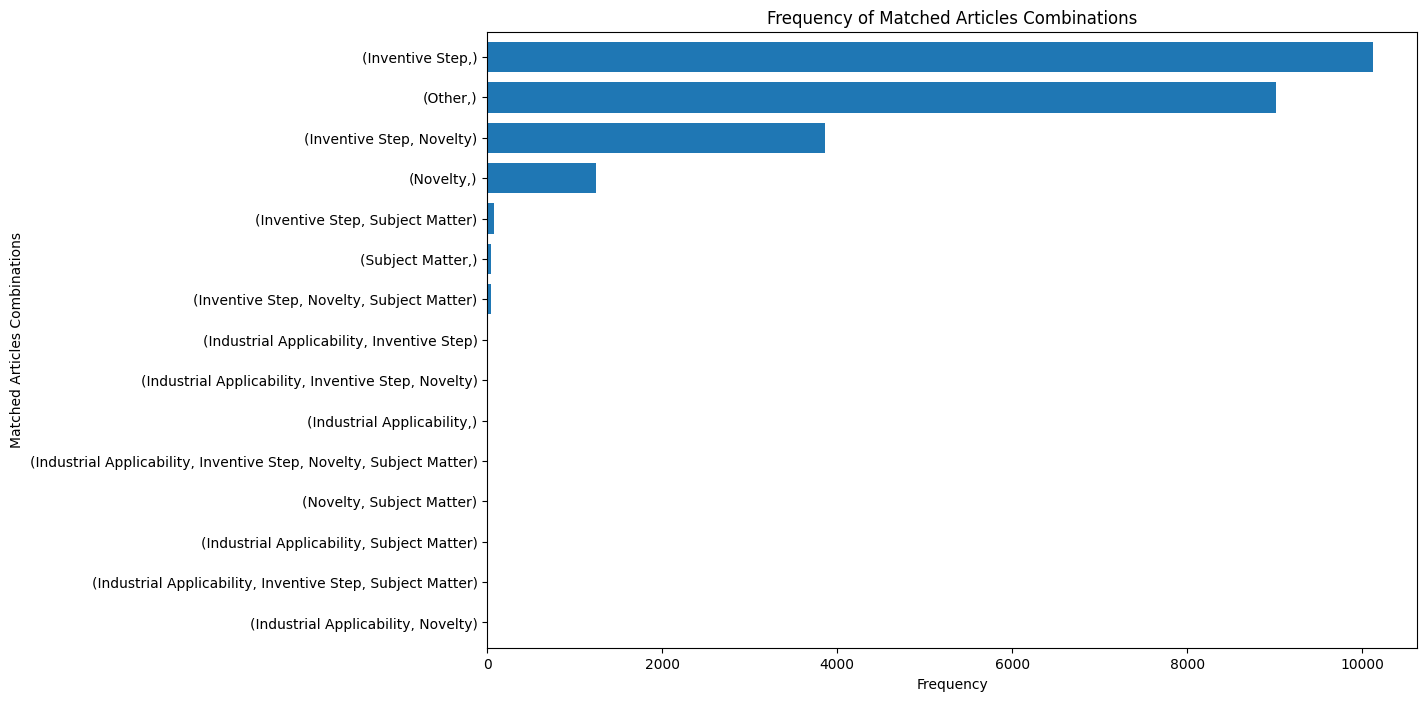

In [48]:
# Frequency of article combinations
matched_articles_combinations = df['Matched Articles'].apply(lambda x: tuple(sorted(x))).value_counts()
matched_articles_combinations = matched_articles_combinations.sort_values(ascending=True)

plt.figure(figsize=(12, 8))
matched_articles_combinations.plot(kind='barh', width=0.75)
plt.title('Frequency of Matched Articles Combinations')
plt.xlabel('Frequency')
plt.ylabel('Matched Articles Combinations')
plt.show()

### Case Type Distribution

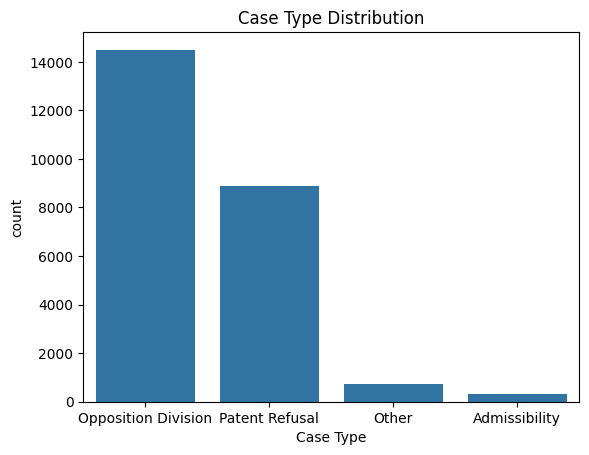

In [49]:
case_type_series = t_df_clean['Matches'].astype(str).replace({'1': 'Opposition Division', '2': 'Opposition Division', '3': 'Opposition Division'})
sns.countplot(x=case_type_series, order=case_type_series.value_counts().index)
plt.title('Case Type Distribution')
plt.xlabel('Case Type')
plt.show()

### Opposition Division Sub-classification Distribution

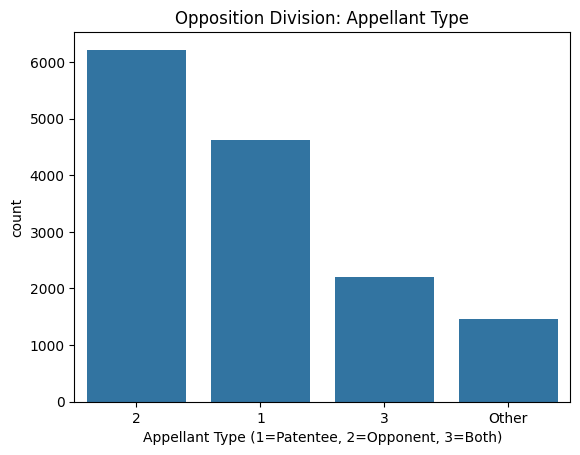

In [50]:
sns.countplot(data=opposition_df_clean, x='Matches')
plt.title('Opposition Division: Appellant Type')
plt.xlabel('Appellant Type (1=Patentee, 2=Opponent, 3=Both)')
plt.show()

### Patent Refusal Outcome Distribution

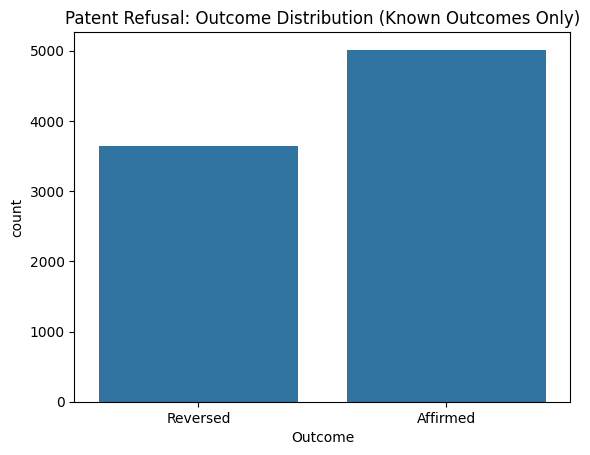

Total PR cases with known outcome: 8,661
Outcome
Affirmed    5013
Reversed    3648
Name: count, dtype: int64


In [51]:
sns.countplot(data=binary_refusal_known, x='Outcome')
plt.title('Patent Refusal: Outcome Distribution (Known Outcomes Only)')
plt.show()

print(f'Total PR cases with known outcome: {len(binary_refusal_known):,}')
print(binary_refusal_known['Outcome'].value_counts())

### Opposition Division Outcome Distribution

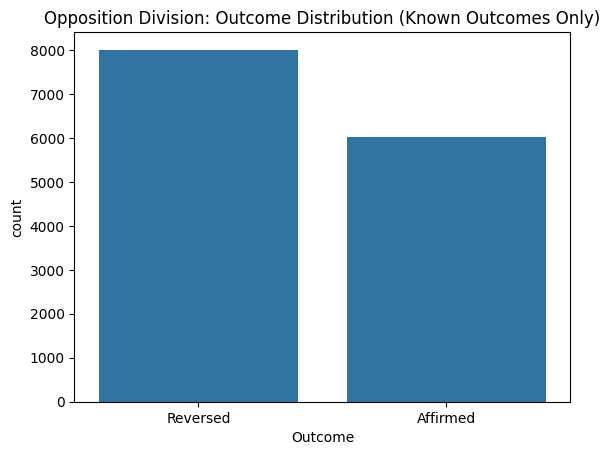

Total OD cases (all): 14,498
OD cases with known outcome: 14,024
Outcome
Reversed    8005
Affirmed    6019
Name: count, dtype: int64


In [52]:
sns.countplot(data=opposition_known, x='Outcome')
plt.title('Opposition Division: Outcome Distribution (Known Outcomes Only)')
plt.show()

print(f'Total OD cases (all): {len(opposition_df_clean):,}')
print(f'OD cases with known outcome: {len(opposition_known):,}')
print(opposition_known['Outcome'].value_counts())

### Combined Outcome Analysis

Outcome distribution across Patent Refusal and Opposition Division combined.

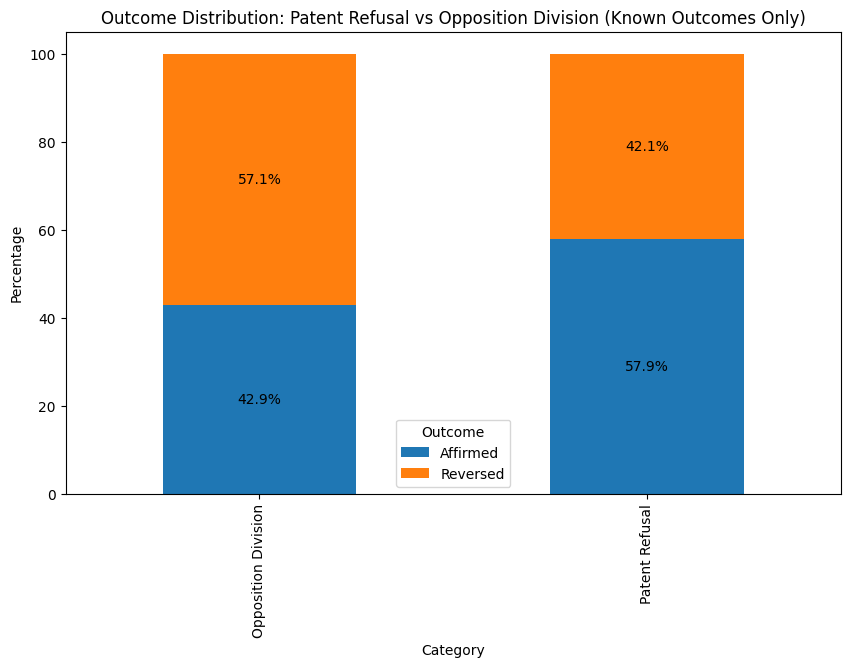

In [53]:
# Merge PR and OD for combined analysis (known outcomes only)
merged_df = pd.concat([opposition_known, binary_refusal_known], ignore_index=True)

# Categorise: Patent Refusal vs Opposition Division
merged_df['Category'] = merged_df['Matches'].apply(
    lambda x: 'Patent Refusal' if x == 'Patent Refusal' else 'Opposition Division'
)

# Pivot: outcome counts per category
pivot_table = merged_df.pivot_table(index='Category', columns='Outcome', aggfunc='size', fill_value=0)
pivot_table_percentage = pivot_table.div(pivot_table.sum(axis=1), axis=0) * 100

ax = pivot_table_percentage.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Outcome Distribution: Patent Refusal vs Opposition Division (Known Outcomes Only)')
plt.xlabel('Category')
plt.ylabel('Percentage')
plt.legend(title='Outcome')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')

plt.show()

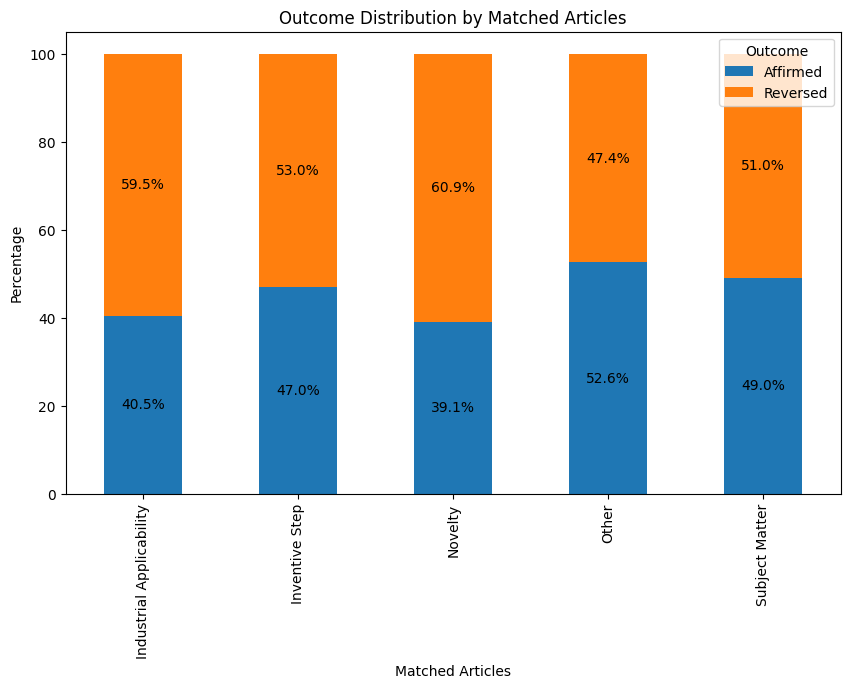

In [54]:
# Outcome distribution by Matched Articles
exploded_df = merged_df.explode('Matched Articles')

pivot_table = exploded_df.pivot_table(index='Matched Articles', columns='Outcome', aggfunc='size', fill_value=0)
pivot_table_percentage = pivot_table.div(pivot_table.sum(axis=1), axis=0) * 100

ax = pivot_table_percentage.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Outcome Distribution by Matched Articles')
plt.xlabel('Matched Articles')
plt.ylabel('Percentage')
plt.legend(title='Outcome')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')

plt.show()

### Inventive Step Outcome by Year

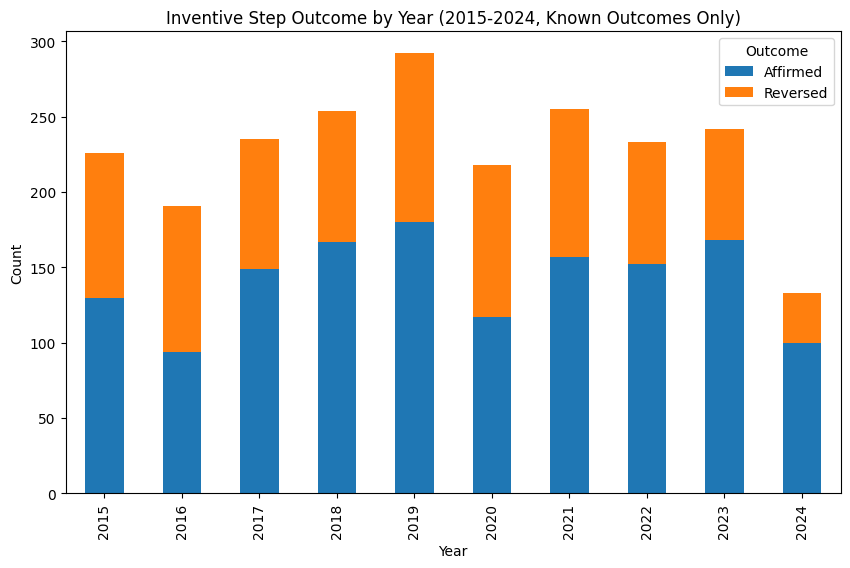

INVENTIVE STEP CASES OUTCOME SUMMARY (2015-2024)

Outcome counts by year:
Outcome  Affirmed  Reversed
Year                       
2015          130        96
2016           94        97
2017          149        86
2018          167        87
2019          180       112
2020          117       101
2021          157        98
2022          152        81
2023          168        74
2024          100        33

Outcome percentages by year:
Outcome  Affirmed  Reversed
Year                       
2015        57.52     42.48
2016        49.21     50.79
2017        63.40     36.60
2018        65.75     34.25
2019        61.64     38.36
2020        53.67     46.33
2021        61.57     38.43
2022        65.24     34.76
2023        69.42     30.58
2024        75.19     24.81


In [55]:
# Inventive Step cases from the PR subset (known outcomes only)
inventive_step_mask = binary_refusal_known['Matched Articles'].astype(str).str.contains('Inventive Step', case=False, na=False)
inventive_step_cases = binary_refusal_known[inventive_step_mask]
inventive_step_2015_2024 = inventive_step_cases[inventive_step_cases['Year'] >= 2015]

outcome_by_year = pd.crosstab(inventive_step_2015_2024['Year'], inventive_step_2015_2024['Outcome'])

outcome_by_year.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Inventive Step Outcome by Year (2015-2024, Known Outcomes Only)')
plt.ylabel('Count')
plt.show()

print('='*60)
print('INVENTIVE STEP CASES OUTCOME SUMMARY (2015-2024)')
print('='*60)
print('\nOutcome counts by year:')
print(outcome_by_year)

print('\nOutcome percentages by year:')
outcome_percentages = outcome_by_year.div(outcome_by_year.sum(axis=1), axis=0) * 100
print(outcome_percentages.round(2))

---

## 2. Matching Validation

This section evaluates the accuracy of the spaCy Matcher patterns used in `data_processing.py` to classify cases and extract outcomes.

For each matcher, a random sample of 50 cases was drawn, manually annotated with the true label in a `REAL` column, and the matcher's prediction compared against it. The annotated `.xlsx` files are stored in `../Data/Matching/`.

| File | What it validates | Labels |
|---|---|---|
| `CaseTypeTest_50.xlsx` | Case type classification (Step 4) | Opposition Division, Patent Refusal, Other |
| `OP_Test_50.xlsx` | Opposition Division appellant sub-type (Step 6) | 1 (Patentee), 2 (Opponent), 3 (Both), Other |
| `PF_Outcome_Test_50.xlsx` | Patent Refusal outcome extraction (Step 7) | Affirmed, Reversed, Unknown |
| `OP_Outcome_Test_50.xlsx` | Opposition Division outcome extraction (Step 7) | Affirmed, Reversed, Unknown |

### 2.1 Case Type Classification

Validates the matcher that classifies cases as **Opposition Division**, **Patent Refusal**, or **Other** based on Summary Facts text.

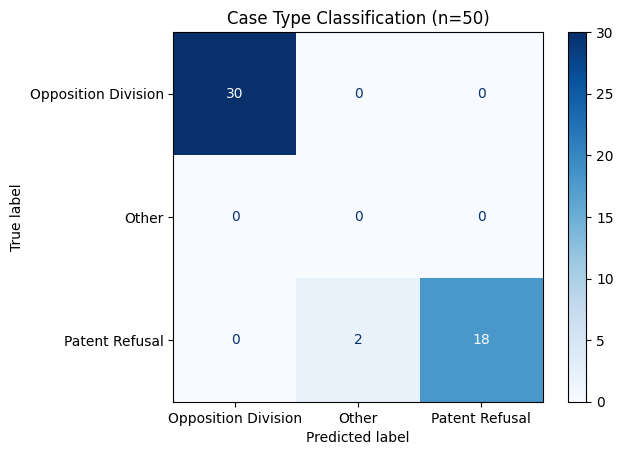

Accuracy: 48/50 = 96.0%


In [56]:
case_type_test = pd.read_excel(os.path.join(MATCHING_DIR, 'CaseTypeTest_50.xlsx'))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(case_type_test['REAL'], case_type_test['Matches']),
    display_labels=['Opposition Division', 'Other', 'Patent Refusal']
)
disp.plot(cmap='Blues')
plt.title('Case Type Classification (n=50)')
plt.show()

# Accuracy
correct = (case_type_test['REAL'] == case_type_test['Matches']).sum()
print(f'Accuracy: {correct}/{len(case_type_test)} = {correct/len(case_type_test)*100:.1f}%')

### 2.2 Opposition Division Sub-classification

Validates the matcher that identifies whether the appeal was filed by the **Patentee (1)**, **Opponent (2)**, **Both (3)**, or **Other**.

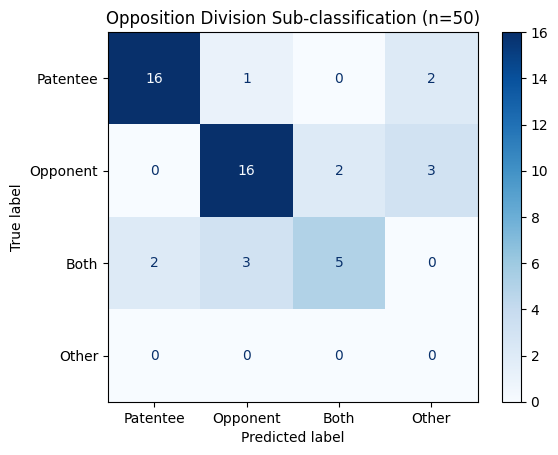

Accuracy: 37/50 = 74.0%


In [57]:
op_type_test = pd.read_excel(os.path.join(MATCHING_DIR, 'OP_Test_50.xlsx'))
op_type_test['REAL'] = op_type_test['REAL'].astype(str)
op_type_test['Matches'] = op_type_test['Matches'].astype(str)

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(op_type_test['REAL'], op_type_test['Matches']),
    display_labels=['Patentee', 'Opponent', 'Both', 'Other']
)
disp.plot(cmap='Blues')
plt.title('Opposition Division Sub-classification (n=50)')
plt.show()

correct = (op_type_test['REAL'] == op_type_test['Matches']).sum()
print(f'Accuracy: {correct}/{len(op_type_test)} = {correct/len(op_type_test)*100:.1f}%')

### 2.3 Patent Refusal Outcome Extraction

Validates the outcome matcher (Affirmed / Reversed / Unknown) on Patent Refusal Order text.

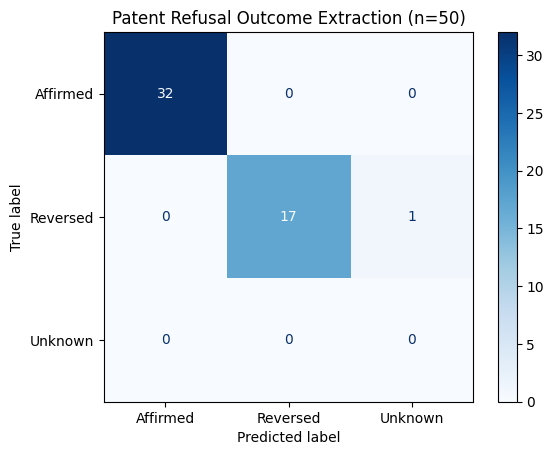

Accuracy: 49/50 = 98.0%


In [58]:
pf_outcome_test = pd.read_excel(os.path.join(MATCHING_DIR, 'PF_Outcome_Test_50.xlsx'))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(pf_outcome_test['REAL'], pf_outcome_test['Matches']),
    display_labels=['Affirmed', 'Reversed', 'Unknown']
)
disp.plot(cmap='Blues')
plt.title('Patent Refusal Outcome Extraction (n=50)')
plt.show()

correct = (pf_outcome_test['REAL'] == pf_outcome_test['Matches']).sum()
print(f'Accuracy: {correct}/{len(pf_outcome_test)} = {correct/len(pf_outcome_test)*100:.1f}%')

### 2.4 Opposition Division Outcome Extraction

Validates the outcome matcher (Affirmed / Reversed / Unknown) on Opposition Division Order text.

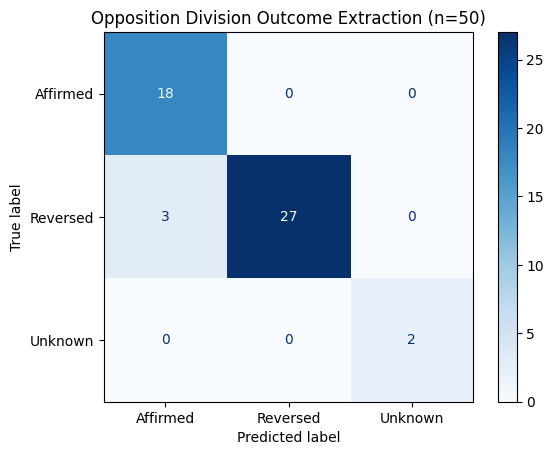

Accuracy: 47/50 = 94.0%


In [59]:
op_outcome_test = pd.read_excel(os.path.join(MATCHING_DIR, 'OP_Outcome_Test_50.xlsx'))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(op_outcome_test['REAL'], op_outcome_test['MatchesOutcome']),
    display_labels=['Affirmed', 'Reversed', 'Unknown']
)
disp.plot(cmap='Blues')
plt.title('Opposition Division Outcome Extraction (n=50)')
plt.show()

correct = (op_outcome_test['REAL'] == op_outcome_test['MatchesOutcome']).sum()
print(f'Accuracy: {correct}/{len(op_outcome_test)} = {correct/len(op_outcome_test)*100:.1f}%')

### 2.5 Matching Validation Summary

In [60]:
# Summary table
results = []

for name, test_df, pred_col in [
    ('Case Type', case_type_test, 'Matches'),
    ('OD Sub-classification', op_type_test, 'Matches'),
    ('PR Outcome', pf_outcome_test, 'Matches'),
    ('OD Outcome', op_outcome_test, 'MatchesOutcome'),
]:
    n = len(test_df)
    correct = (test_df['REAL'] == test_df[pred_col]).sum()
    acc = correct / n * 100
    results.append({'Matcher': name, 'n': n, 'Correct': correct, 'Accuracy (%)': f'{acc:.1f}'})

summary = pd.DataFrame(results)
summary

,Matcher,n,Correct,Accuracy (%)
0,Case Type,50,48,96.0
1,OD Sub-classification,50,37,74.0
2,PR Outcome,50,49,98.0
3,OD Outcome,50,47,94.0


## 3. Final Experiment Data Splits — Visualisations

Visualisations for the train/test splits produced by `data_processing_experiments.py`.  
Run that script first to generate the pkl files in `Data/Final_Processed/`.


In [ ]:
from pathlib import Path

FINAL_OUTPUT_DIR = Path(DATA_DIR) / 'Final_Processed'


def plot_binary_dist(y_train, y_test, title=''):
    """Countplot of train/test label distributions (0=Reversed, 1=Affirmed)."""
    def to_series(y):
        s = pd.Series(y.iloc[:, 0].values if hasattr(y, 'iloc') else y)
        return s.map({1: 'Affirmed', 0: 'Reversed'})

    fig, axs = plt.subplots(ncols=2, figsize=(10, 4))
    sns.countplot(x=to_series(y_train), order=['Affirmed', 'Reversed'], ax=axs[0])
    sns.countplot(x=to_series(y_test),  order=['Affirmed', 'Reversed'], ax=axs[1])
    axs[0].set_title('Train')
    axs[1].set_title('Test')
    axs[0].set_xlabel('Outcome')
    axs[1].set_xlabel('Outcome')
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


### 3.1 Patent Refusal — Experiment 1 & 2


PR (known outcomes): 8,661 rows  (dropped 0)


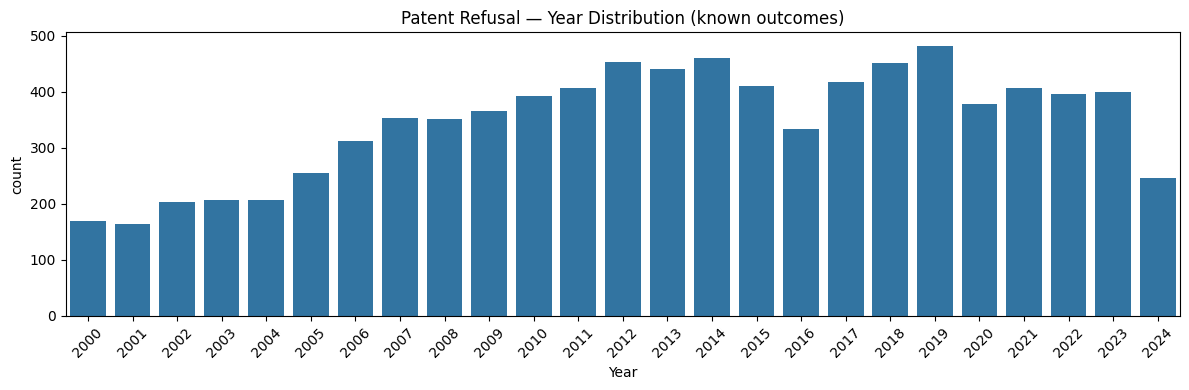

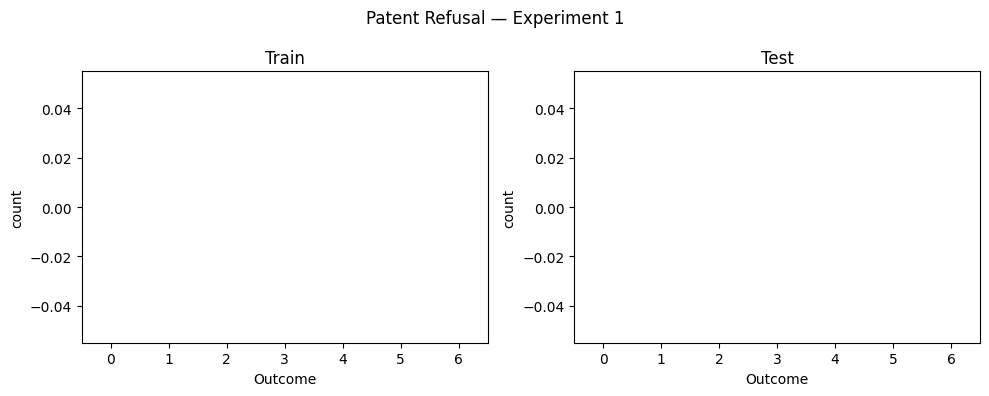

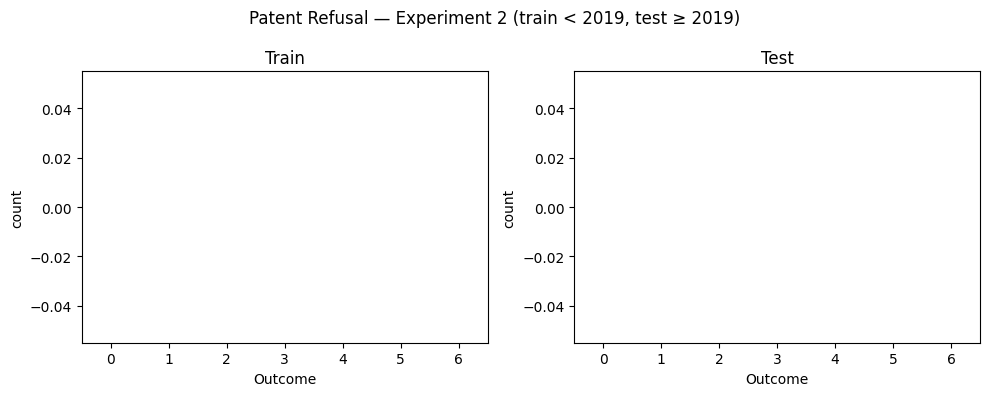

In [68]:
# Patent Refusal: keep known outcomes only
pf_raw_all = pd.read_pickle(os.path.join(DATA_DIR, 'Train&TestData_1.0_PatentRefusal.pkl'))
pf_raw = pf_raw_all[pf_raw_all['Outcome'].isin(['Affirmed', 'Reversed'])].copy()
print(f'PR (known outcomes): {len(pf_raw):,} rows  (dropped {len(pf_raw_all) - len(pf_raw):,})')

plt.figure(figsize=(12, 4))
sns.countplot(data=pf_raw, x='Year')
plt.xticks(rotation=45)
plt.title('Patent Refusal — Year Distribution (known outcomes)')
plt.tight_layout()
plt.show()

# Experiment 1 — train/test label distribution
y_train_pf1 = pd.read_pickle(FINAL_OUTPUT_DIR / 'y_Train_1_pf.pkl')
y_test_pf1  = pd.read_pickle(FINAL_OUTPUT_DIR / 'y_test_1_pf.pkl')
plot_binary_dist(y_train_pf1, y_test_pf1, 'Patent Refusal — Experiment 1')

# Experiment 2 — train/test label distribution
y_train_pf2 = pd.read_pickle(FINAL_OUTPUT_DIR / 'y_Train_2_pf.pkl')
y_test_pf2  = pd.read_pickle(FINAL_OUTPUT_DIR / 'y_test_2_pf.pkl')
plot_binary_dist(y_train_pf2, y_test_pf2, 'Patent Refusal — Experiment 2 (train < 2019, test ≥ 2019)')


### 3.2 Opposition Division — Experiment 1 & 2


OD (known outcomes, Matches 1/2/3): 12,639 rows  (dropped 1,859)


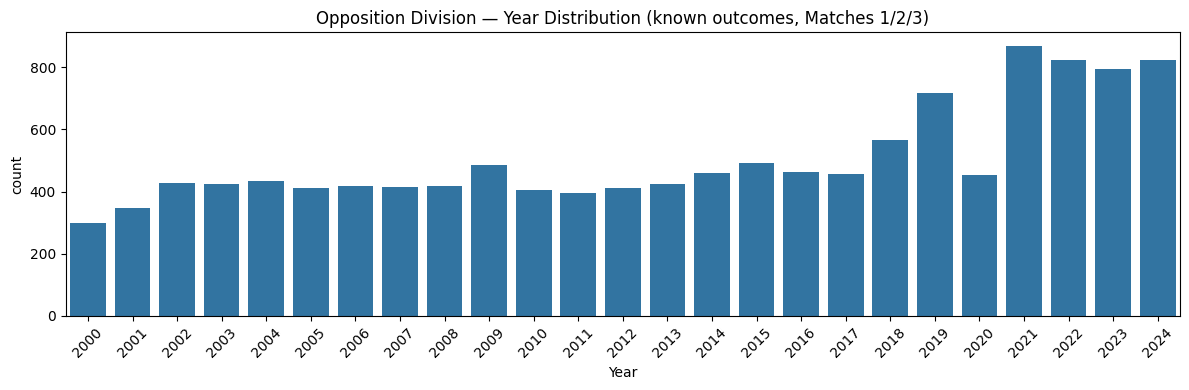

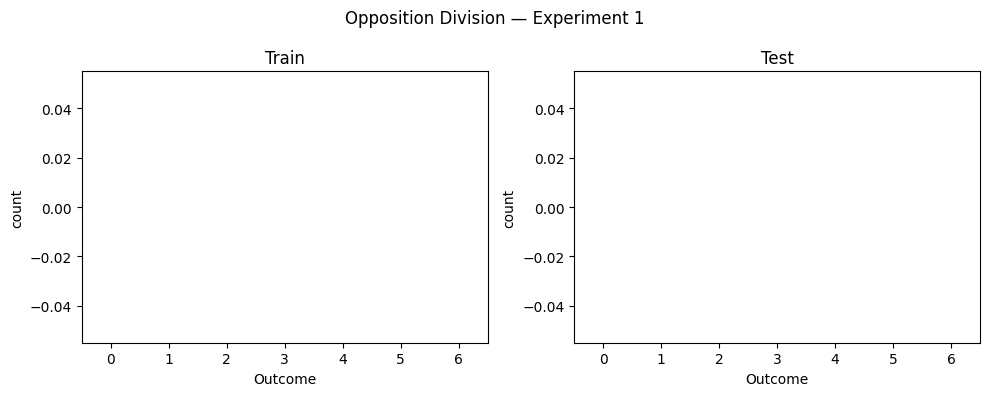

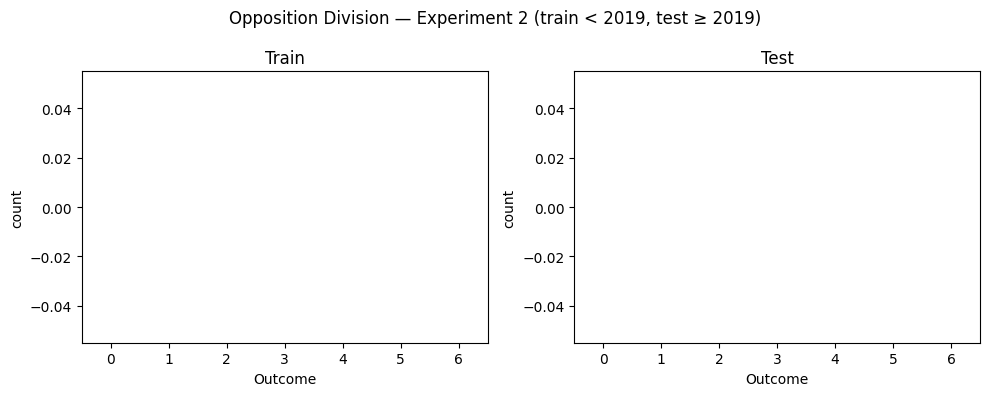

In [63]:
# Opposition Division: keep known outcomes and valid sub-classifications (1, 2, 3) only
op_raw_all = pd.read_pickle(os.path.join(DATA_DIR, 'Train&TestData_1.0_OppositionDivision.pkl'))
op_raw = op_raw_all[
    op_raw_all['Outcome'].isin(['Affirmed', 'Reversed']) &
    op_raw_all['Matches'].isin(['1', '2', '3'])
].copy()
print(f'OD (known outcomes, Matches 1/2/3): {len(op_raw):,} rows  (dropped {len(op_raw_all) - len(op_raw):,})')

plt.figure(figsize=(12, 4))
sns.countplot(data=op_raw, x='Year')
plt.xticks(rotation=45)
plt.title('Opposition Division — Year Distribution (known outcomes, Matches 1/2/3)')
plt.tight_layout()
plt.show()

# Experiment 1 — train/test label distribution
y_train_op1 = pd.read_pickle(FINAL_OUTPUT_DIR / 'y_Train_1_op.pkl')
y_test_op1  = pd.read_pickle(FINAL_OUTPUT_DIR / 'y_test_1_op.pkl')
plot_binary_dist(y_train_op1, y_test_op1, 'Opposition Division — Experiment 1')

# Experiment 2 — train/test label distribution
y_train_op2 = pd.read_pickle(FINAL_OUTPUT_DIR / 'y_Train_2_op.pkl')
y_test_op2  = pd.read_pickle(FINAL_OUTPUT_DIR / 'y_test_2_op.pkl')
plot_binary_dist(y_train_op2, y_test_op2, 'Opposition Division — Experiment 2 (train < 2019, test ≥ 2019)')


### 3.3 Final Combined Experiment (Patent Refusal + Opposition Division)


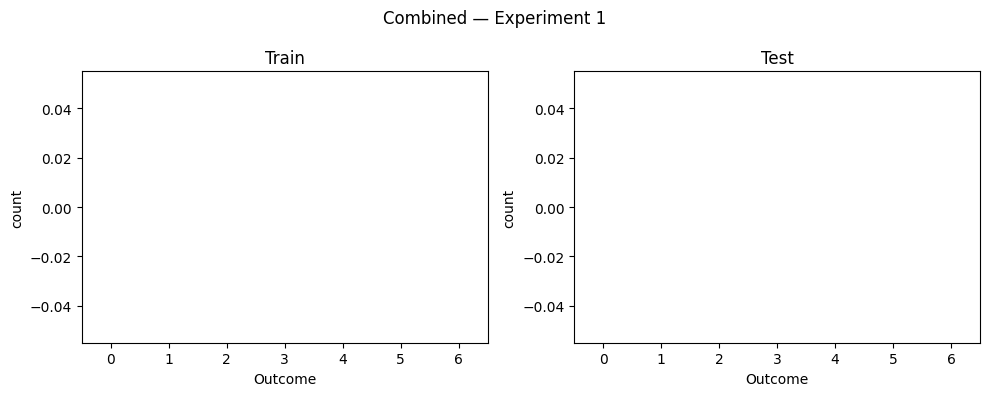

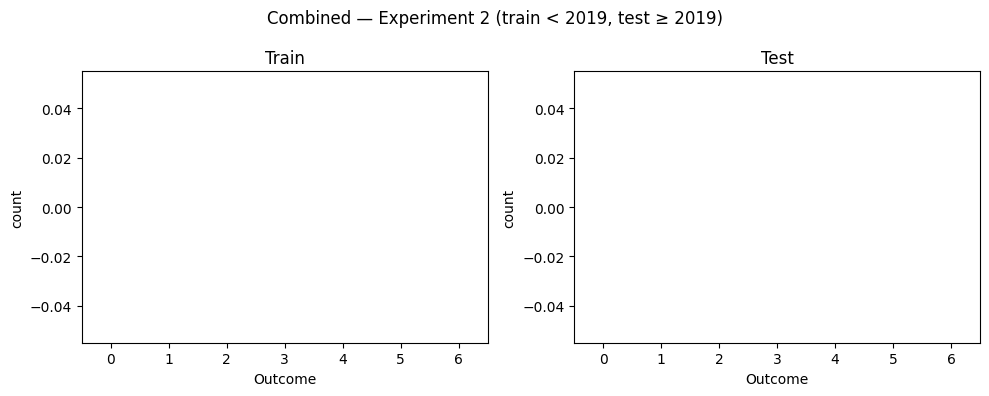

Combined rows: 21,300  (PR=8,661, OD=12,639)


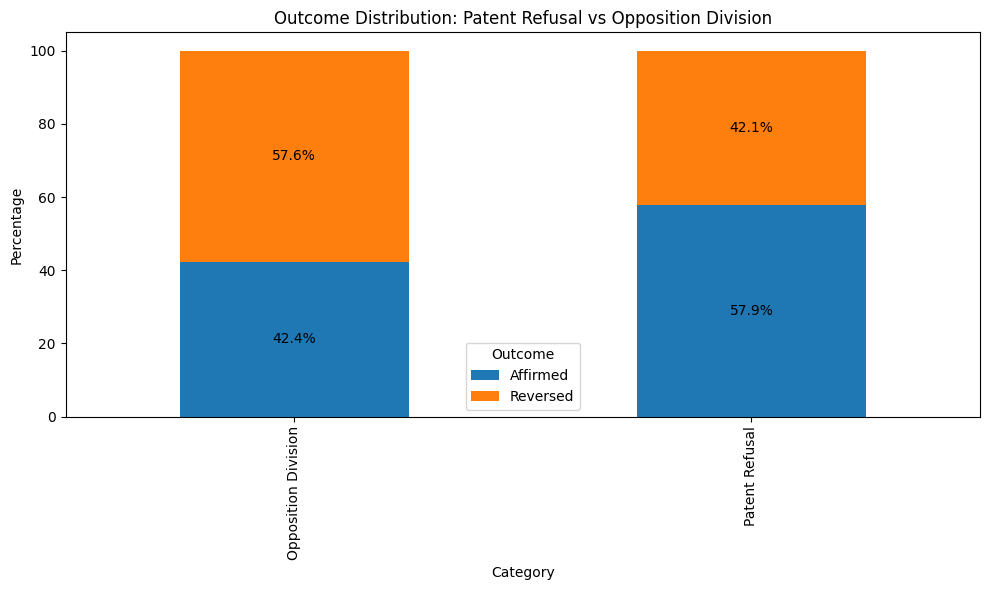

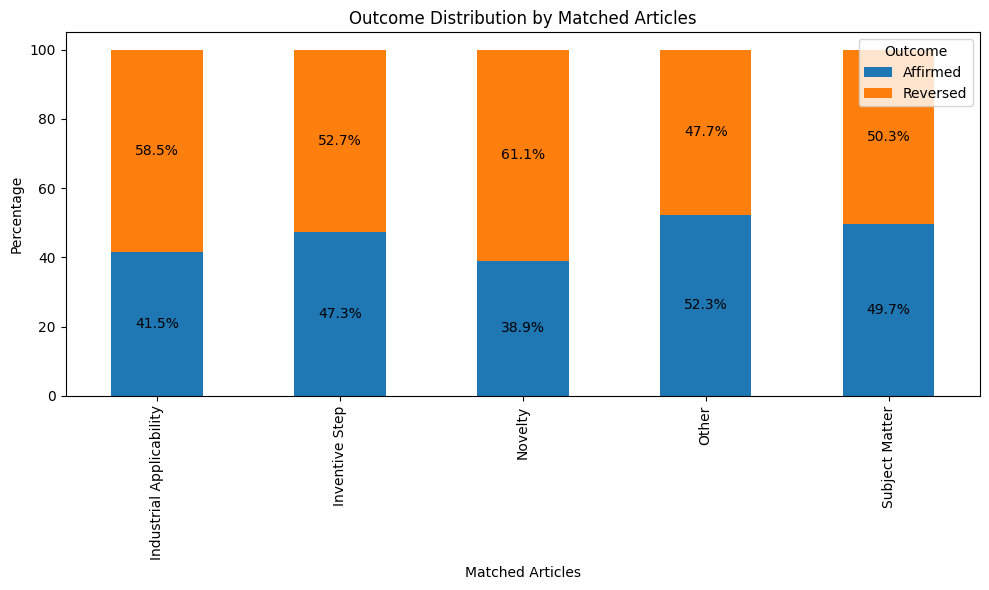

In [64]:
# Combined label distributions
y_train_b1 = pd.read_pickle(FINAL_OUTPUT_DIR / 'y_Train_1_both.pkl')
y_test_b1  = pd.read_pickle(FINAL_OUTPUT_DIR / 'y_test_1_both.pkl')
plot_binary_dist(y_train_b1, y_test_b1, 'Combined — Experiment 1')

y_train_b2 = pd.read_pickle(FINAL_OUTPUT_DIR / 'y_Train_2_both.pkl')
y_test_b2  = pd.read_pickle(FINAL_OUTPUT_DIR / 'y_test_2_both.pkl')
plot_binary_dist(y_train_b2, y_test_b2, 'Combined — Experiment 2 (train < 2019, test ≥ 2019)')

# pf_raw and op_raw are already filtered (known outcomes; OD also Matches 1/2/3)
pf_raw['Category'] = 'Patent Refusal'
op_raw['Category'] = 'Opposition Division'
combined_df = pd.concat([pf_raw, op_raw], ignore_index=True)
print(f'Combined rows: {len(combined_df):,}  (PR={len(pf_raw):,}, OD={len(op_raw):,})')

# Stacked % bar: outcome by category (PR vs OD)
pivot = combined_df.pivot_table(index='Category', columns='Outcome', aggfunc='size', fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

ax = pivot_pct.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Outcome Distribution: Patent Refusal vs Opposition Division')
plt.xlabel('Category')
plt.ylabel('Percentage')
plt.legend(title='Outcome')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')
plt.tight_layout()
plt.show()

# Stacked % bar: outcome by matched article
exploded = combined_df.explode('Matched Articles')
pivot_ma = exploded.pivot_table(index='Matched Articles', columns='Outcome', aggfunc='size', fill_value=0)
pivot_ma_pct = pivot_ma.div(pivot_ma.sum(axis=1), axis=0) * 100

ax = pivot_ma_pct.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Outcome Distribution by Matched Articles')
plt.xlabel('Matched Articles')
plt.ylabel('Percentage')
plt.legend(title='Outcome')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')
plt.tight_layout()
plt.show()
